# Supervised ViT fine-tune ablation: ResNet distillation + MixUp

Классификация 26 видов. Абляция объединяет ResNet18 teacher distillation, умеренный MixUp и больший вес hard labels.

**Чекпоинт:** `checkpoints/vit_lfpe_bat_ablation_distill_mixup_best.pt`

**Идея:** сохранить пользу teacher soft targets, но сильнее привязать модель к истинным меткам и сгладить скачки validation через MixUp.


In [1]:
from pathlib import Path
import os
import sys
import warnings
import math

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import soundfile as sf
from scipy import signal
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
)
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from IPython.display import display
from tqdm.auto import tqdm

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)


# ClearML и пути

Пути к данным и чекпоинтам, загрузка `.env`, device (`mps`), инициализация ClearML Task и OutputModel.


In [2]:
PROJECT_DIR = Path("/Users/katterns/ITMO/Practice")
sys.path.insert(0, str(PROJECT_DIR))

DATA_DIR = PROJECT_DIR / "cleaned_subset_200"
METADATA_PATH = DATA_DIR / "audio_metadata_cleaned.csv"
CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
SSL_PRETRAIN_CKPT = CHECKPOINT_DIR / "vit_lfpe_ssl_pretrain_best.pt"
BEST_CKPT = CHECKPOINT_DIR / "vit_lfpe_bat_ablation_distill_mixup_best.pt"
TRAIN_LOG_TXT = CHECKPOINT_DIR / "vit_lfpe_bat_ablation_distill_mixup_log.txt"

import logging
from dotenv import load_dotenv

load_dotenv(PROJECT_DIR / ".env", override=False)

CLEARML_QUIET = os.environ.get("CLEARML_QUIET", "1").strip().lower() in ("1", "true", "yes")
CLEARML_UPLOAD_EACH_BEST = os.environ.get("CLEARML_UPLOAD_EACH_BEST", "0").strip().lower() in (
    "1", "true", "yes",
)


def setup_clearml_console(quiet: bool = True) -> None:
    if not quiet:
        return
    for name in ("clearml", "clearml.storage", "clearml.model", "clearml.Task"):
        logging.getLogger(name).setLevel(logging.WARNING)
    try:
        from clearml.storage.callbacks import ProgressReport

        def _no_tqdm(self):
            self._tqdm_init = True
            return None

        ProgressReport._get_tqdm = _no_tqdm
    except Exception:
        pass


setup_clearml_console(CLEARML_QUIET)

from clearml import OutputModel, Task

device = torch.device("mps")

# --- ClearML ---
RESUME_FROM_BEST = False
CLEARML_CONTINUE_LAST = False
CLEARML_TASK_ID = None
CLEARML_PROJECT = "my project"
CLEARML_TASK_NAME = "vit_lfpe_bat_ablation_distill_mixup_2sec"

clearml_output_uri = os.environ.get("CLEARML_OUTPUT_URI", True)
if isinstance(clearml_output_uri, str) and clearml_output_uri.lower() in ("false", "0", "no", "none"):
    clearml_output_uri = False

_task_init_kw = dict(
    project_name=CLEARML_PROJECT,
    task_name=CLEARML_TASK_NAME,
    output_uri=clearml_output_uri,
    auto_resource_monitoring=False,
)
if CLEARML_TASK_ID:
    _task_init_kw["continue_last_task"] = CLEARML_TASK_ID
    _task_init_kw["reuse_last_task_id"] = CLEARML_TASK_ID
elif CLEARML_CONTINUE_LAST and RESUME_FROM_BEST:
    _task_init_kw["continue_last_task"] = 0
    _task_init_kw["reuse_last_task_id"] = True
else:
    _task_init_kw["reuse_last_task_id"] = False

clearml_task = Task.init(**_task_init_kw)
output_dest = clearml_task.get_output_destination() or ""
output_model = OutputModel(
    task=clearml_task,
    name="vit_lfpe_bat_ablation_distill_mixup",
    framework="pytorch",
)
if output_dest:
    output_model.set_upload_destination(output_dest)

if not CLEARML_QUIET:
    print("ClearML:", clearml_task.get_output_log_web_page())
print(
    "device:", device,
    "| quiet:", CLEARML_QUIET,
    "| upload each best:", CLEARML_UPLOAD_EACH_BEST,
    "| clearml continue:", (CLEARML_CONTINUE_LAST and RESUME_FROM_BEST) or bool(CLEARML_TASK_ID),
    "| clearml task:", clearml_task.id,
)

ClearML Task: created new task id=9fa48577eb544319863a4f256263d0a4
ClearML results page: https://app.clear.ml/projects/6c3eac4aaa974ff39b83424d3f26990c/experiments/9fa48577eb544319863a4f256263d0a4/output/log
device: mps | quiet: True | upload each best: False | clearml continue: False | clearml task: 9fa48577eb544319863a4f256263d0a4


# Аудио, STFT и аугментации

**192 kHz**, клип **2 с**.

**Train:** energy-biased или random crop; jitter громкости на waveform (±6 dB); log-STFT; SpecAugment (freq/time mask, gain на спектрограмме).

**Val:** center crop, без аугментаций.


In [3]:
TARGET_SR = 192_000
CLIP_SEC = 2.0
MIN_FREQ = 5_000
MAX_FREQ = 96_000
SPEC_H, SPEC_W = 128, 256
N_FFT = 2048
HOP_LENGTH = 512

SPEC_TIME_MASK_MAX = 24
SPEC_FREQ_MASK_MAX = 16
GAIN_JITTER_DB = 6.0

ENERGY_CROP_PROB = 0.7
ENERGY_CROP_CANDIDATES = 8
WAV_GAIN_JITTER_DB = 6.0


def resample_audio(y: np.ndarray, orig_sr: float, target_sr: float) -> np.ndarray:
    if int(orig_sr) == int(target_sr):
        return y.astype(np.float32)
    t_old = np.linspace(0.0, len(y) / orig_sr, num=len(y), endpoint=False)
    t_new = np.linspace(
        0.0,
        len(y) / orig_sr,
        num=int(len(y) * target_sr / orig_sr),
        endpoint=False,
    )
    return np.interp(t_new, t_old, y).astype(np.float32)


def center_crop_or_pad(y: np.ndarray, target_len: int) -> np.ndarray:
    if len(y) >= target_len:
        i0 = (len(y) - target_len) // 2
        return y[i0 : i0 + target_len]
    out = np.zeros(target_len, dtype=np.float32)
    i0 = (target_len - len(y)) // 2
    out[i0 : i0 + len(y)] = y
    return out


def random_crop_or_pad(y: np.ndarray, target_len: int, rng: np.random.Generator) -> np.ndarray:
    if len(y) >= target_len:
        i0 = int(rng.integers(0, len(y) - target_len + 1))
        return y[i0 : i0 + target_len]
    out = np.zeros(target_len, dtype=np.float32)
    i0 = (target_len - len(y)) // 2
    out[i0 : i0 + len(y)] = y
    return out


def energy_biased_crop(
    y: np.ndarray, target_len: int, rng: np.random.Generator, n_candidates: int
) -> np.ndarray:
    if len(y) < target_len:
        return center_crop_or_pad(y, target_len)
    best_i0, best_e = 0, -1.0
    for _ in range(n_candidates):
        i0 = int(rng.integers(0, len(y) - target_len + 1))
        seg = y[i0 : i0 + target_len]
        e = float(np.mean(seg * seg))
        if e > best_e:
            best_e, best_i0 = e, i0
    return y[best_i0 : best_i0 + target_len]


def pick_train_crop(y: np.ndarray, target_len: int, rng: np.random.Generator) -> np.ndarray:
    if rng.random() < ENERGY_CROP_PROB:
        return energy_biased_crop(y, target_len, rng, ENERGY_CROP_CANDIDATES)
    return random_crop_or_pad(y, target_len, rng)


def maybe_gain_jitter(y: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    if WAV_GAIN_JITTER_DB <= 0:
        return y
    gain = 10.0 ** (float(rng.uniform(-WAV_GAIN_JITTER_DB, WAV_GAIN_JITTER_DB)) / 20.0)
    return (y * gain).astype(np.float32)


def make_log_stft(audio: np.ndarray, sr: float) -> np.ndarray:
    audio = np.asarray(audio, dtype=np.float32)
    audio = audio[np.isfinite(audio)]
    if len(audio) < 8:
        raise ValueError("Audio too short")
    nperseg = int(min(N_FFT, len(audio)))
    hop = int(min(HOP_LENGTH, max(1, nperseg // 2)))
    noverlap = max(0, nperseg - hop)
    if noverlap >= nperseg:
        noverlap = nperseg - 1
    freqs, _, zxx = signal.stft(
        audio,
        fs=sr,
        nperseg=nperseg,
        noverlap=noverlap,
        boundary="zeros",
        padded=True,
    )
    spec = np.log1p(np.abs(zxx))
    keep = (freqs >= MIN_FREQ) & (freqs <= min(MAX_FREQ, sr / 2))
    return spec[keep]


def spec_to_tensor(spec: np.ndarray) -> torch.Tensor:
    spec = np.ascontiguousarray(spec, dtype=np.float32)
    x = torch.from_numpy(spec)[None, None]
    x = F.interpolate(x, size=(SPEC_H, SPEC_W), mode="bilinear", align_corners=False)
    x = x[0]
    x = (x - x.mean()) / (x.std().clamp_min(1e-6))
    return x


def augment_spec(x: torch.Tensor, rng: np.random.Generator) -> torch.Tensor:
    _, h, w = x.shape
    if SPEC_FREQ_MASK_MAX > 0:
        fh = int(rng.integers(0, SPEC_FREQ_MASK_MAX + 1))
        if fh > 0:
            f0 = int(rng.integers(0, max(1, h - fh)))
            x = x.clone()
            x[:, f0 : f0 + fh, :] = 0.0
    if SPEC_TIME_MASK_MAX > 0:
        tw = int(rng.integers(0, SPEC_TIME_MASK_MAX + 1))
        if tw > 0:
            t0 = int(rng.integers(0, max(1, w - tw)))
            x = x.clone()
            x[:, :, t0 : t0 + tw] = 0.0
    if GAIN_JITTER_DB > 0:
        gain = 10.0 ** (float(rng.uniform(-GAIN_JITTER_DB, GAIN_JITTER_DB)) / 20.0)
        x = x * gain
    return x


# Датасет (метаданные)

CSV с путями к WAV, фильтрация отсутствующих файлов, stratified split 85/15 по виду.


In [4]:
df = pd.read_csv(METADATA_PATH)
assert not df.empty, f"Пустой CSV: {METADATA_PATH}"

species_sorted = sorted(df["species"].unique())
label2id = {s: i for i, s in enumerate(species_sorted)}
id2label = {i: s for s, i in label2id.items()}
n_classes = len(species_sorted)

df["label"] = df["species"].map(label2id)
df["path"] = df.apply(
    lambda r: DATA_DIR / str(r["species"]) / str(r["filename"]), axis=1
)
df = df[df["path"].apply(lambda p: p.is_file())].reset_index(drop=True)

train_df, val_df = train_test_split(
    df,
    test_size=0.15,
    random_state=RANDOM_SEED,
    stratify=df["label"],
)
print(f"Train: {len(train_df)}  Val: {len(val_df)}  Классов: {n_classes}")

vc_train = train_df["species"].value_counts().sort_values()
print(
    f"Классы train: min={vc_train.min()} max={vc_train.max()} "
    f"ratio={vc_train.max() / max(vc_train.min(), 1):.2f}"
)
display(vc_train.head(8))


Train: 4348  Val: 768  Классов: 26
Классы train: min=133 max=170 ratio=1.28


species
LABL    133
COTO    142
NYMA    163
LASE    170
MYYU    170
MYSO    170
MYVO    170
PAHE    170
Name: count, dtype: int64

# Dataset

`BatWavSpectrogramDataset` читает WAV, режет клип, считает log-STFT, нормализует и отдаёт тензор `[1, 128, 256]` и метку класса.


In [5]:
class BatWavSpectrogramDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, training: bool = False):
        self.frame = frame.reset_index(drop=True)
        self.training = training
        self.rng = np.random.default_rng(RANDOM_SEED)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        y, sr = sf.read(str(row["path"]), always_2d=False)
        if y.ndim > 1:
            y = y.mean(axis=-1)
        y = resample_audio(y, float(sr), float(TARGET_SR))
        tgt = int(CLIP_SEC * TARGET_SR)
        if self.training:
            y = pick_train_crop(y, tgt, self.rng)
            y = maybe_gain_jitter(y, self.rng)
        else:
            y = center_crop_or_pad(y, tgt)
        spec = make_log_stft(y, float(TARGET_SR))
        x = spec_to_tensor(spec)
        if self.training:
            x = augment_spec(x, self.rng)
        return x, int(row["label"])


# DataLoader

Train: `WeightedRandomSampler` (обратно пропорционально частоте класса). Batch size 8 — из‑за ViT на спектрограмме 128×256.


In [6]:
train_ds = BatWavSpectrogramDataset(train_df, training=True)
val_ds = BatWavSpectrogramDataset(val_df, training=False)

label_counts = train_df["label"].value_counts().sort_index()
inv_count = {lbl: 1.0 / cnt for lbl, cnt in label_counts.items()}
sample_weights = train_df["label"].map(inv_count).values
train_sampler = torch.utils.data.WeightedRandomSampler(
    weights=torch.as_tensor(
        np.asarray(sample_weights, dtype=np.float64).copy(), dtype=torch.double
    ),
    num_samples=len(train_df),
    replacement=True,
)

BATCH_SIZE = 8
NUM_WORKERS = 0

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    num_workers=NUM_WORKERS,
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

xb, yb = next(iter(train_loader))
print("batch:", xb.shape, "labels:", yb.shape)


batch: torch.Size([8, 1, 128, 256]) labels: torch.Size([8])


# ViT classifier: ResNet distillation

Тот же ViT encoder/head, но training loss смешивает CE по hard labels и KL distillation от `resnet18_bat_best.pt`.


In [7]:
from vit_bat import (
    ConvPosEnc1d,
    LearnableFourierPosEncoding,
    PatchEmbed2D,
    TransformerBlock,
    make_normalized_grid,
)

PATCH_SIZE = (16, 16)
EMBED_DIM = 256
DEPTH = 8
N_HEADS = 4
MLP_RATIO = 4.0
DROPOUT = 0.1
PE_TYPE = "lf"  # "lf" (C0) or "sine" (C1)
POOL_TYPE = "mean"


class BatViTClassifier(nn.Module):
    def __init__(
        self,
        n_classes,
        embed_dim=256,
        depth=8,
        n_heads=4,
        patch_size=(8, 16),
        mlp_ratio=4.0,
        dropout=0.1,
        pe_type="lf",
        pool_type="mean",
    ):
        super().__init__()
        self.patch_embed = PatchEmbed2D(1, embed_dim, patch_size)
        self.pe_type = pe_type
        self.pool_type = pool_type
        grid_f = SPEC_H // patch_size[0]
        grid_t = SPEC_W // patch_size[1]
        self.grid_shape = (grid_f, grid_t)

        if pe_type == "lf":
            self.pos_encoder = LearnableFourierPosEncoding(pe_dim=embed_dim)
        else:
            raise ValueError(f"Unknown pe_type: {pe_type}")

        self.conv_pos = ConvPosEnc1d(embed_dim)
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, n_heads, mlp_ratio, dropout)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        head_in = embed_dim * 2 if pool_type == "mean_max" else embed_dim
        self.head = nn.Sequential(
            nn.LayerNorm(head_in),
            nn.Dropout(0.2),
            nn.Linear(head_in, n_classes),
        )

    def _patch_positional_encoding(self, batch_size, device):
        positions = make_normalized_grid(self.grid_shape, device=device)
        pe = self.pos_encoder(positions)
        return pe.unsqueeze(0).expand(batch_size, -1, -1)

    def _pool_tokens(self, tokens: torch.Tensor) -> torch.Tensor:
        if self.pool_type == "mean":
            return tokens.mean(dim=1)
        if self.pool_type == "mean_max":
            return torch.cat([tokens.mean(dim=1), tokens.max(dim=1).values], dim=-1)
        raise ValueError(f"Unknown pool_type: {self.pool_type}")

    def forward(self, x):
        tokens, _ = self.patch_embed(x)
        b = tokens.shape[0]
        tokens = tokens + self._patch_positional_encoding(b, tokens.device)
        tokens = self.conv_pos(tokens)
        for block in self.blocks:
            tokens = block(tokens)
        tokens = self.norm(tokens)
        return self.head(self._pool_tokens(tokens))

    def encoder_parameters(self):
        for name, param in self.named_parameters():
            if not name.startswith("head."):
                yield param


def _assert_ssl_config_compatible(ckpt_cfg: dict) -> None:
    expected = {
        "spec_hw": (SPEC_H, SPEC_W),
        "patch_size": PATCH_SIZE,
        "embed_dim": EMBED_DIM,
        "n_heads": N_HEADS,
        "pe_type": PE_TYPE,
    }
    aliases = {"depth": "enc_depth"}
    errors = []
    for key, expected_value in expected.items():
        actual = ckpt_cfg.get(key)
        if isinstance(actual, list):
            actual = tuple(actual)
        if actual is not None and actual != expected_value:
            errors.append(f"{key}: ckpt={actual} current={expected_value}")
    enc_depth = ckpt_cfg.get("enc_depth", ckpt_cfg.get("depth"))
    if enc_depth is not None and enc_depth != DEPTH:
        errors.append(f"enc_depth: ckpt={enc_depth} current={DEPTH}")
    if errors:
        raise ValueError("SSL checkpoint config несовместим с classifier: " + "; ".join(errors))


def load_ssl_encoder(classifier, ckpt_path, strict=False):
    if not ckpt_path.is_file():
        raise FileNotFoundError(
            f"SSL pretrain: нет файла {ckpt_path}. "
            "Сначала запустите vit_lfpe_ssl_pretrain.ipynb с PATCH_SIZE=(8, 16)."
        )
    try:
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    except TypeError:
        ckpt = torch.load(ckpt_path, map_location=device)
    ckpt_cfg = dict(ckpt.get("config", {}))
    ckpt_cfg["epoch"] = ckpt.get("epoch")
    ckpt_cfg["val_recon_loss"] = ckpt.get("val_recon_loss")
    _assert_ssl_config_compatible(ckpt_cfg)
    enc = ckpt.get("encoder_state") or {}
    if not enc:
        raise KeyError("В чекпоинте нет encoder_state")
    missing, unexpected = classifier.load_state_dict(enc, strict=strict)
    other_missing = [k for k in missing if not k.startswith("head.")]
    if other_missing:
        tqdm.write(f"SSL load missing keys: {other_missing}")
    if unexpected:
        tqdm.write(f"SSL load unexpected keys: {unexpected}")
    return ckpt_cfg


model = BatViTClassifier(
    n_classes,
    embed_dim=EMBED_DIM,
    depth=DEPTH,
    n_heads=N_HEADS,
    patch_size=PATCH_SIZE,
    mlp_ratio=MLP_RATIO,
    dropout=DROPOUT,
    pe_type=PE_TYPE,
    pool_type=POOL_TYPE,
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"ViT params: {n_params:,}  PE={PE_TYPE}  patch={PATCH_SIZE}  pool={POOL_TYPE}")

LOAD_SSL_PRETRAIN = True
_ssl_ok = False
_ssl_cfg = {}
if LOAD_SSL_PRETRAIN:
    _ssl_cfg = load_ssl_encoder(model, SSL_PRETRAIN_CKPT, strict=False)
    _ssl_ok = True
    print("SSL encoder loaded:", SSL_PRETRAIN_CKPT)
    print("SSL epoch:", _ssl_cfg.get("epoch", "n/a"), "| SSL val recon:", _ssl_cfg.get("val_recon_loss", "n/a"))
else:
    print("SSL pretrain skipped (random init encoder)")

with torch.no_grad():
    print("logits:", model(xb.to(device)).shape)

ViT params: 6,568,410  PE=lf  patch=(16, 16)  pool=mean
SSL encoder loaded: /Users/katterns/ITMO/Practice/checkpoints/vit_lfpe_ssl_pretrain_best.pt
SSL epoch: 100 | SSL val recon: 0.794361246128877
logits: torch.Size([8, 26])


# Гиперпараметры

AdamW с разным LR для encoder и head, `ReduceLROnPlateau` по macro-F1, label smoothing 0.1, grad clip, early stopping.


In [8]:
WEIGHT_DECAY = 3e-4
LABEL_SMOOTHING = 0.05
MAX_EPOCHS = 55
PATIENCE = 15
LR_PLATEAU_PATIENCE = 8
LR_FACTOR = 0.5
LR_MIN = 1e-7
MAX_GRAD_NORM = 1.0

RESUME_LOWER_LR = False
FINETUNE_ENCODER_LR = 5e-5
FINETUNE_HEAD_LR = 1e-4

# p8x16 has more tokens; start with a real fine-tune LR, not an almost-frozen encoder.
ENCODER_LR = 1e-4 if _ssl_ok else 5e-4
HEAD_LR = 3e-4
TEACHER_CKPT = CHECKPOINT_DIR / "resnet18_bat_best.pt"
DISTILL_ALPHA = 0.65  # hard soft-label CE weight
DISTILL_TEMPERATURE = 2.0
MIXUP_ALPHA = 0.15
MIXUP_PROB = 0.50


clearml_task.connect({
    "model": "vit_lfpe_ablation_distill_mixup",
    "ssl_pretrain_ckpt": str(SSL_PRETRAIN_CKPT),
    "clip_sec": CLIP_SEC,
    "energy_crop_prob": ENERGY_CROP_PROB,
    "batch_size": BATCH_SIZE,
    "encoder_lr": ENCODER_LR,
    "head_lr": HEAD_LR,
    "label_smoothing": LABEL_SMOOTHING,
    "teacher_ckpt": str(TEACHER_CKPT),
    "distill_alpha": DISTILL_ALPHA,
    "distill_temperature": DISTILL_TEMPERATURE,
    "mixup_alpha": MIXUP_ALPHA,
    "mixup_prob": MIXUP_PROB,
    "spec_hw": (SPEC_H, SPEC_W),
    "patch_size": PATCH_SIZE,
    "embed_dim": EMBED_DIM,
    "depth": DEPTH,
    "n_heads": N_HEADS,
    "pe_type": PE_TYPE,
    "pool_type": POOL_TYPE,
    "ssl_pretrain_loaded": _ssl_ok,
    "device": str(device),
    "resume_from_best": RESUME_FROM_BEST,
    "clearml_continue_last": CLEARML_CONTINUE_LAST,
})

loss_function = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = optim.AdamW(
    [
        {"params": model.encoder_parameters(), "lr": ENCODER_LR},
        {"params": model.head.parameters(), "lr": HEAD_LR},
    ],
    lr=HEAD_LR,
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=LR_FACTOR,
    patience=LR_PLATEAU_PATIENCE,
    min_lr=LR_MIN,
)

from torchvision.models import resnet18


class ResNet18BatTeacher(nn.Module):
    def __init__(self, n_classes: int, dropout: float = 0.3):
        super().__init__()
        backbone = resnet18(weights=None)
        backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        in_features = backbone.fc.in_features
        backbone.fc = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, n_classes),
        )
        self.backbone = backbone

    def forward(self, x):
        return self.backbone(x)


def load_resnet_teacher(ckpt_path: Path) -> nn.Module:
    if not ckpt_path.is_file():
        raise FileNotFoundError(f"Teacher checkpoint not found: {ckpt_path}")
    try:
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    except TypeError:
        ckpt = torch.load(ckpt_path, map_location=device)
    teacher = ResNet18BatTeacher(n_classes).to(device)
    teacher.load_state_dict(ckpt["model_state"], strict=True)
    teacher.eval()
    for p in teacher.parameters():
        p.requires_grad = False
    print(
        "Teacher loaded:", ckpt_path,
        "| epoch:", ckpt.get("epoch"),
        "| macro_f1:", ckpt.get("val_macro_f1"),
    )
    return teacher


teacher_model = load_resnet_teacher(TEACHER_CKPT)


def soft_cross_entropy(logits: torch.Tensor, soft_targets: torch.Tensor) -> torch.Tensor:
    return -(soft_targets * F.log_softmax(logits, dim=-1)).sum(dim=-1).mean()


def mixup_batch(batch_x: torch.Tensor, target: torch.Tensor):
    if MIXUP_ALPHA <= 0 or torch.rand((), device=batch_x.device).item() > MIXUP_PROB:
        return batch_x, F.one_hot(target, n_classes).float(), 1.0
    lam = float(np.random.beta(MIXUP_ALPHA, MIXUP_ALPHA))
    lam = max(lam, 1.0 - lam)
    perm = torch.randperm(batch_x.size(0), device=batch_x.device)
    mixed_x = lam * batch_x + (1.0 - lam) * batch_x[perm]
    y1 = F.one_hot(target, n_classes).float()
    y2 = F.one_hot(target[perm], n_classes).float()
    mixed_y = lam * y1 + (1.0 - lam) * y2
    return mixed_x, mixed_y, lam


def distillation_loss(student_logits, soft_target, teacher_logits):
    hard = soft_cross_entropy(student_logits, soft_target)
    t = DISTILL_TEMPERATURE
    soft = F.kl_div(
        F.log_softmax(student_logits / t, dim=-1),
        F.softmax(teacher_logits / t, dim=-1),
        reduction="batchmean",
    ) * (t * t)
    return DISTILL_ALPHA * hard + (1.0 - DISTILL_ALPHA) * soft


Teacher loaded: /Users/katterns/ITMO/Practice/checkpoints/resnet18_bat_best.pt | epoch: 40 | macro_f1: 0.8182081594190671


# Обучение

`evaluate` — loss и метрики на validation. `train_model` — цикл по эпохам, лог в ClearML и txt, сохранение лучшего чекпоинта по macro-F1.

При `RESUME_FROM_BEST=True` загружается лучший чекпоинт и обучение продолжается с epoch+1 (опционально с пониженным LR).


In [9]:
@torch.no_grad()
def evaluate(model):
    model.eval()
    loss_epoch = 0.0
    num_samples = 0
    preds_list, targets_list = [], []

    for batch_x, target in val_loader:
        batch_x = batch_x.to(device)
        target = target.to(device)
        logits = model(batch_x)
        loss = loss_function(logits, target)
        num = logits.shape[0]
        loss_epoch += loss.item() * num
        num_samples += num
        preds_list.extend(logits.argmax(dim=-1).cpu().tolist())
        targets_list.extend(target.cpu().tolist())

    y_true = np.array(targets_list)
    y_pred = np.array(preds_list)
    metrics = {
        "acc": accuracy_score(y_true, y_pred),
        "bal_acc": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "weighted_prec": precision_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
    }
    return loss_epoch / max(num_samples, 1), metrics, y_true, y_pred


def _upload_checkpoint_to_clearml(epoch: int) -> str | None:
    if not output_dest:
        return None
    return output_model.update_weights(
        weights_filename=str(BEST_CKPT),
        upload_uri=output_dest or None,
        auto_delete_file=False,
        iteration=epoch,
    )


def _save_best_checkpoint(epoch, macro_f1, metrics):
    torch.save(
        {
            "model_state": model.state_dict(),
            "model_name": "vit_lfpe_bat",
            "label2id": label2id,
            "id2label": {str(k): v for k, v in id2label.items()},
            "config": {
                "target_sr": TARGET_SR,
                "clip_sec": CLIP_SEC,
                "min_freq": MIN_FREQ,
                "max_freq": MAX_FREQ,
                "spec_hw": (SPEC_H, SPEC_W),
                "n_fft": N_FFT,
                "hop_length": HOP_LENGTH,
                "patch_size": PATCH_SIZE,
                "embed_dim": EMBED_DIM,
                "depth": DEPTH,
                "n_heads": N_HEADS,
                "pe_type": PE_TYPE,
                "pool_type": POOL_TYPE,
                "ssl_pretrain_ckpt": str(SSL_PRETRAIN_CKPT),
                "ssl_pretrain_loaded": _ssl_ok,
                "encoder_lr": ENCODER_LR,
                "head_lr": HEAD_LR,
                "label_smoothing": LABEL_SMOOTHING,
                "teacher_ckpt": str(TEACHER_CKPT),
                "distill_alpha": DISTILL_ALPHA,
                "distill_temperature": DISTILL_TEMPERATURE,
                "mixup_alpha": MIXUP_ALPHA,
                "mixup_prob": MIXUP_PROB,
                "energy_crop_prob": ENERGY_CROP_PROB,
            },
            "val_macro_f1": macro_f1,
            "val_weighted_f1": metrics["weighted_f1"],
            "val_balanced_acc": metrics["bal_acc"],
            "epoch": epoch,
        },
        BEST_CKPT,
    )
    model_uri = None
    if CLEARML_UPLOAD_EACH_BEST:
        model_uri = _upload_checkpoint_to_clearml(epoch)
    line = f"epoch={epoch} macro_f1={macro_f1:.4f} w_f1={metrics['weighted_f1']:.4f}\n"
    TRAIN_LOG_TXT.write_text(
        (TRAIN_LOG_TXT.read_text(encoding="utf-8") if TRAIN_LOG_TXT.exists() else "")
        + line,
        encoding="utf-8",
    )
    if CLEARML_QUIET:
        tqdm.write(f"saved {BEST_CKPT.name}  macro_f1={macro_f1:.4f}")
    else:
        msg = f"saved {BEST_CKPT}"
        if model_uri:
            msg += f"  ClearML: {model_uri}"
        tqdm.write(msg)


def _load_resume_checkpoint(model, ckpt_path: Path):
    if not ckpt_path.is_file():
        raise FileNotFoundError(f"Resume: нет файла {ckpt_path}")

    try:
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    except TypeError:
        ckpt = torch.load(ckpt_path, map_location=device)

    model.load_state_dict(ckpt["model_state"], strict=True)

    ckpt_labels = ckpt.get("label2id") or {}
    if set(ckpt_labels.keys()) != set(label2id.keys()):
        tqdm.write("WARNING: label2id в чекпоинте отличается от текущего split")

    last_epoch = int(ckpt.get("epoch", 0))
    best_macro_f1 = float(ckpt.get("val_macro_f1", -1.0))
    start_epoch = last_epoch + 1
    return start_epoch, best_macro_f1, last_epoch


def _apply_finetune_lr():
    for pg in optimizer.param_groups:
        is_encoder = pg is optimizer.param_groups[0]
        pg["lr"] = FINETUNE_ENCODER_LR if is_encoder else FINETUNE_HEAD_LR
    tqdm.write(
        f"Finetune LR: encoder={FINETUNE_ENCODER_LR:.2e} head={FINETUNE_HEAD_LR:.2e}"
    )


def train_model(
    model,
    num_epochs=40,
    max_grad_norm=1.0,
    resume_from_best: bool = False,
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_macro_f1": [],
        "val_weighted_f1": [],
        "val_acc": [],
    }
    best_macro_f1 = -1.0
    best_epoch = 0
    epochs_no_improve = 0
    start_epoch = 1

    if resume_from_best:
        start_epoch, best_macro_f1, best_epoch = _load_resume_checkpoint(model, BEST_CKPT)
        if RESUME_LOWER_LR:
            _apply_finetune_lr()
        tqdm.write(
            f"Resume: {BEST_CKPT.name}  last_epoch={best_epoch}  "
            f"best_macro_f1={best_macro_f1:.4f}, epochs {start_epoch}..{num_epochs}"
        )
        if start_epoch > num_epochs:
            raise ValueError(
                f"Resume: start_epoch={start_epoch} > MAX_EPOCHS={num_epochs}."
            )

    logger = clearml_task.get_logger()

    epoch_bar = tqdm(
        range(start_epoch, num_epochs + 1),
        desc="epochs",
        unit="epoch",
        initial=start_epoch - 1,
        total=num_epochs,
    )
    for epoch in epoch_bar:
        model.train()
        epoch_train_loss = 0.0
        epoch_train_n = 0

        batch_bar = tqdm(
            train_loader,
            desc=f"train e{epoch}",
            leave=False,
            unit="batch",
            position=1,
        )
        for batch_x, target in batch_bar:
            batch_x = batch_x.to(device)
            target = target.to(device)
            optimizer.zero_grad(set_to_none=True)
            train_x, soft_target, _mix_lam = mixup_batch(batch_x, target)
            logits = model(train_x)
            with torch.no_grad():
                teacher_logits = teacher_model(train_x)
            loss = distillation_loss(logits, soft_target, teacher_logits)
            loss.backward()
            if max_grad_norm is not None:
                nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            optimizer.step()

            batch_n = batch_x.size(0)
            epoch_train_loss += loss.item() * batch_n
            epoch_train_n += batch_n
            batch_bar.set_postfix(loss=f"{loss.item():.4f}")

        tr_loss = epoch_train_loss / max(epoch_train_n, 1)
        val_loss, metrics, y_true, y_pred = evaluate(model)
        lr_now = optimizer.param_groups[0]["lr"]
        macro_f1 = metrics["macro_f1"]

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(val_loss)
        history["val_macro_f1"].append(macro_f1)
        history["val_weighted_f1"].append(metrics["weighted_f1"])
        history["val_acc"].append(metrics["acc"])

        for name, val in metrics.items():
            logger.report_scalar("metrics", name, val, iteration=epoch)
        logger.report_scalar("loss", "train", tr_loss, iteration=epoch)
        logger.report_scalar("loss", "val", val_loss, iteration=epoch)
        logger.report_scalar("lr", "lr", lr_now, iteration=epoch)

        pred_top3 = pd.Series(y_pred).map(id2label).value_counts().head(3).to_dict()
        epoch_bar.set_postfix(macro_f1=f"{macro_f1:.4f}", val_loss=f"{val_loss:.4f}")
        tqdm.write(
            f"Epoch {epoch:02d}  lr={lr_now:.2e}  train={tr_loss:.4f}  val={val_loss:.4f}  "
            f"acc={metrics['acc']:.4f}  macro_f1={macro_f1:.4f}  "
            f"w_f1={metrics['weighted_f1']:.4f}  w_prec={metrics['weighted_prec']:.4f}  "
            f"top3={pred_top3}"
        )

        if macro_f1 > best_macro_f1:
            best_macro_f1 = macro_f1
            best_epoch = epoch
            epochs_no_improve = 0
            _save_best_checkpoint(epoch, macro_f1, metrics)
        else:
            epochs_no_improve += 1

        scheduler.step(macro_f1)

        if epochs_no_improve >= PATIENCE:
            tqdm.write("Early stopping.")
            break

    epoch_bar.close()
    if best_macro_f1 > 0 and output_dest and not CLEARML_UPLOAD_EACH_BEST:
        uri = _upload_checkpoint_to_clearml(best_epoch)
        if not CLEARML_QUIET and uri:
            tqdm.write(f"ClearML upload (final best, ep {best_epoch}): {uri}")
    tqdm.write(f"best macro_f1 (val): {best_macro_f1:.4f}")
    return model, history


# Запуск обучения



In [10]:
model, history = train_model(
    model,
    num_epochs=MAX_EPOCHS,
    max_grad_norm=MAX_GRAD_NORM,
    resume_from_best=RESUME_FROM_BEST,
)


epochs:   0%|          | 0/55 [00:00<?, ?epoch/s]

train e1:   0%|          | 0/544 [00:00<?, ?batch/s]

Epoch 01  lr=1.00e-04  train=2.0395  val=1.7787  acc=0.4909  macro_f1=0.4363  w_f1=0.4386  w_prec=0.5347  top3={'MYEV': 85, 'MYTH': 64, 'LASE': 61}
saved vit_lfpe_bat_ablation_distill_mixup_best.pt  macro_f1=0.4363


train e2:   0%|          | 0/544 [00:00<?, ?batch/s]

Epoch 02  lr=1.00e-04  train=1.5718  val=1.5879  acc=0.5260  macro_f1=0.5035  w_f1=0.5064  w_prec=0.5178  top3={'MYTH': 61, 'MYEV': 50, 'MYSE': 47}
saved vit_lfpe_bat_ablation_distill_mixup_best.pt  macro_f1=0.5035


...

Epoch 53  lr=1.00e-04  train=0.6072  val=1.1716  acc=0.7279  macro_f1=0.7254  w_f1=0.7247  w_prec=0.7306  top3={'MYTH': 41, 'MYSE': 39, 'LANO': 37}


train e54:   0%|          | 0/544 [00:00<?, ?batch/s]

Epoch 54  lr=1.00e-04  train=0.6189  val=1.1611  acc=0.7448  macro_f1=0.7429  w_f1=0.7418  w_prec=0.7616  top3={'MYLE': 44, 'MYVO': 43, 'MYTH': 40}


train e55:   0%|          | 0/544 [00:00<?, ?batch/s]

Epoch 55  lr=1.00e-04  train=0.6236  val=1.1640  acc=0.7292  macro_f1=0.7279  w_f1=0.7270  w_prec=0.7379  top3={'MYSE': 44, 'MYTH': 39, 'LABL': 39}
best macro_f1 (val): 0.7446


# Оценка на validation

Загрузка лучшего чекпоинта, macro-F1 / weighted-F1, classification report, confusion matrix.


epoch: 52
macro F1: 0.744623238832572
weighted F1: 0.7442024177247388
weighted precision: 0.757557511444892
balanced acc: 0.7488019451812555
accuracy: 0.74609375

              precision    recall  f1-score   support

        ANPA       0.58      0.60      0.59        30
        COTO       0.72      0.92      0.81        25
        EPFU       0.76      0.43      0.55        30
        EUMA       0.97      1.00      0.98        30
        LABL       0.58      0.92      0.71        24
        LABO       0.67      0.60      0.63        30
        LACI       0.69      0.67      0.68        30
        LAIN       0.97      0.93      0.95        30
        LANO       0.68      0.90      0.77        30
        LASE       0.90      0.87      0.88        30
        MYCA       0.48      0.53      0.51        30
        MYCI       0.59      0.53      0.56        30
        MYEV       0.93      0.93      0.93        30
        MYGR       0.93      0.90      0.92        30
        MYLE       0.71   

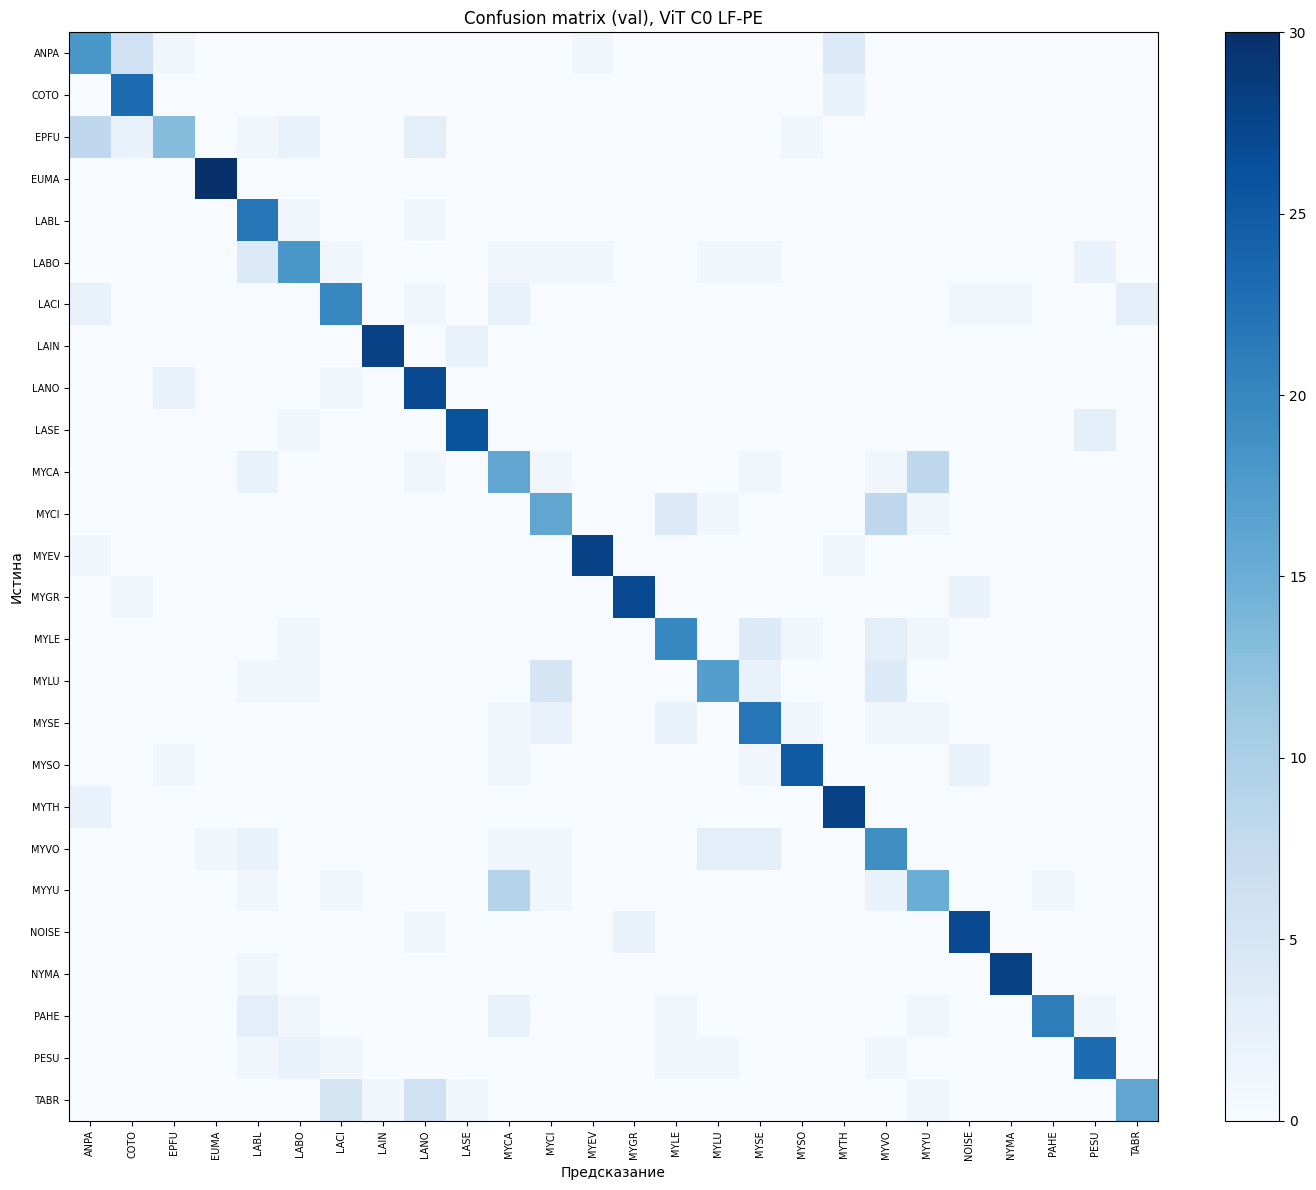

In [11]:
ckpt = torch.load(BEST_CKPT, map_location=device, weights_only=False)

model.load_state_dict(ckpt["model_state"])

val_loss, metrics, y_true, y_pred = evaluate(model)
print("epoch:", ckpt.get("epoch"))
print("macro F1:", metrics["macro_f1"])
print("weighted F1:", metrics["weighted_f1"])
print("weighted precision:", metrics["weighted_prec"])
print("balanced acc:", metrics["bal_acc"])
print("accuracy:", metrics["acc"])
print()
print(classification_report(y_true, y_pred, target_names=species_sorted, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(np.arange(n_classes))
ax.set_yticks(np.arange(n_classes))
ax.set_xticklabels(species_sorted, rotation=90, fontsize=7)
ax.set_yticklabels(species_sorted, fontsize=7)
ax.set_ylabel("Истина")
ax.set_xlabel("Предсказание")
ax.set_title("Confusion matrix (val), ViT C0 LF-PE")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()
